<a href="https://colab.research.google.com/github/ExTc-aShiSh/Introduction-to-AI/blob/main/4_queen_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# Function to print the board configuration
def print_board(board):
    for row in board:
        print(" ".join("Q" if col else "." for col in row))
    print("\n")

# Function to check if a queen can be placed on board[row][col]
# This function checks the column and both diagonals
def is_safe(board, row, col):
    # Check the column
    for i in range(row):
        if board[i][col] == 1:
            return False

    # Check the upper-left diagonal
    for i, j in zip(range(row - 1, -1, -1), range(col - 1, -1, -1)):
        if board[i][j] == 1:
            return False

    # Check the upper-right diagonal
    for i, j in zip(range(row - 1, -1, -1), range(col + 1, len(board))):
        if board[i][j] == 1:
            return False

    return True

# Backtracking function to solve the problem
def solve_n_queens(board, row):
    # If all queens are placed, return True
    if row == len(board):
        return True

    # Try placing the queen in each column of the current row
    for col in range(len(board)):
        # Check if it's safe to place a queen at board[row][col]
        if is_safe(board, row, col):
            board[row][col] = 1  # Place the queen

            # Recur to place the queen in the next row
            if solve_n_queens(board, row + 1):
                return True

            # Backtrack if placing queen in board[row][col] doesn't lead to a solution
            board[row][col] = 0

    # If no place is found, return False
    return False

# Function to solve the N Queens problem
def four_queens():
    n = 4  # Number of queens
    board = [[0 for _ in range(n)] for _ in range(n)]  # Initialize the board

    # Start the backtracking algorithm from the first row
    if solve_n_queens(board, 0):
        return board
    else:
        return None


Solution found:


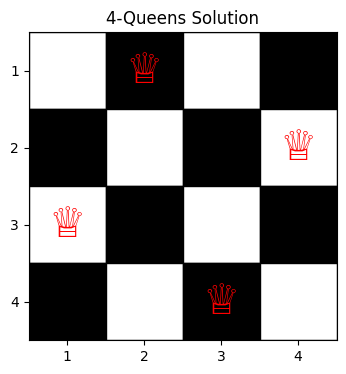

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_n_queens(board):
    n = len(board)
    if n == 0: # Handle empty board case gracefully
        print("Empty board provided, nothing to visualize.")
        return

    fig, ax = plt.subplots(figsize=(n, n))

    # Draw the chessboard
    for i in range(n):
        for j in range(n):
            color = 'white' if (i + j) % 2 == 0 else 'black'
            ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=color, edgecolor='black'))

    # Place queens
    for r in range(n):
        for c in range(n):
            if board[r][c] == 1:
                ax.text(c + 0.5, r + 0.5, '♕', fontsize=30, ha='center', va='center', color='red')

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_xticks(np.arange(n) + 0.5, labels=[str(i+1) for i in range(n)])
    ax.set_yticks(np.arange(n) + 0.5, labels=[str(i+1) for i in range(n)])
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'{n}-Queens Solution')
    plt.gca().invert_yaxis() # Invert y-axis to match typical board representation (row 0 at top)
    plt.show()

# Get the solved board from the four_queens function
solved_board = four_queens()

if solved_board:
    print("Solution found:")
    visualize_n_queens(solved_board)
else:
    print("No solution exists for 4-Queens problem.")